In [2]:
import tensorflow as tf

#x, y의 데이터 값

data = [[2, 81], [4, 93], [6, 91], [8, 97]]

x_train = [x_row[0] for x_row in data]
y_train = [y_row[1] for y_row in data]

w = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=0))

#기울기와 절편을 통해 계싼되는 예상 Y값
def hypothesis(w,b):
    return x_train * w + b
def cost(w, b):
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(w,b) - y_train)))

opt = tf.keras.optimizers.SGD(learning_rate = 0.1)
for i in range(2000):
    #자동 미분을 위한 테이프
    with tf.GradientTape() as tape:
        loss = cost(w, b) #기록할 내용이 w, b임을 명시
    gradients = tape.gradient(loss, [w, b]) #손실에 대한 w, b의 미분값 계산
    opt.apply_gradients(zip(gradients, [w, b])) #미분값으로 w와 b를 업데이트 (조정)
    if i % 100 == 0:
        print(i, f'{loss.numpy()}, {w.numpy()}, {b.numpy()}')

0 31.108581142537346, [7.5236665], [78.22530992]
100 2.9076305897916037, [2.46033278], [78.04320254]
200 2.8896758579816764, [2.39146795], [78.4541584]
300 2.8837958465269438, [2.35207199], [78.68925662]
400 2.881886281135822, [2.32962379], [78.82321789]
500 2.881267844754225, [2.31684923], [78.89945103]
600 2.881067735644112, [2.3095827], [78.94281455]
700 2.881003004574224, [2.30544986], [78.96747755]
800 2.880982067404832, [2.30309942], [78.98150401]
900 2.8809752955136854, [2.30176268], [78.98948108]
1000 2.8809731052434207, [2.30100246], [78.99401776]
1100 2.8809723968344256, [2.30057011], [78.99659782]
1200 2.8809721677107434, [2.30032423], [78.99806514]
1300 2.880972093604337, [2.30018439], [78.99889962]
1400 2.8809720696358028, [2.30010487], [78.9993742]
1500 2.880972061883564, [2.30005964], [78.9996441]
1600 2.880972059376226, [2.30003392], [78.9997976]
1700 2.8809720585652703, [2.30001929], [78.99988489]
1800 2.880972058302976, [2.30001097], [78.99993454]
1900 2.8809720582181

<2018년 우리나라의 지역 별 인구 증가율과 고령인구비율 사이에 어떤 경향성이 있는지 선형회귀로 예측>
- X: 인구 증가율
- Y: 노인 인구 증가율

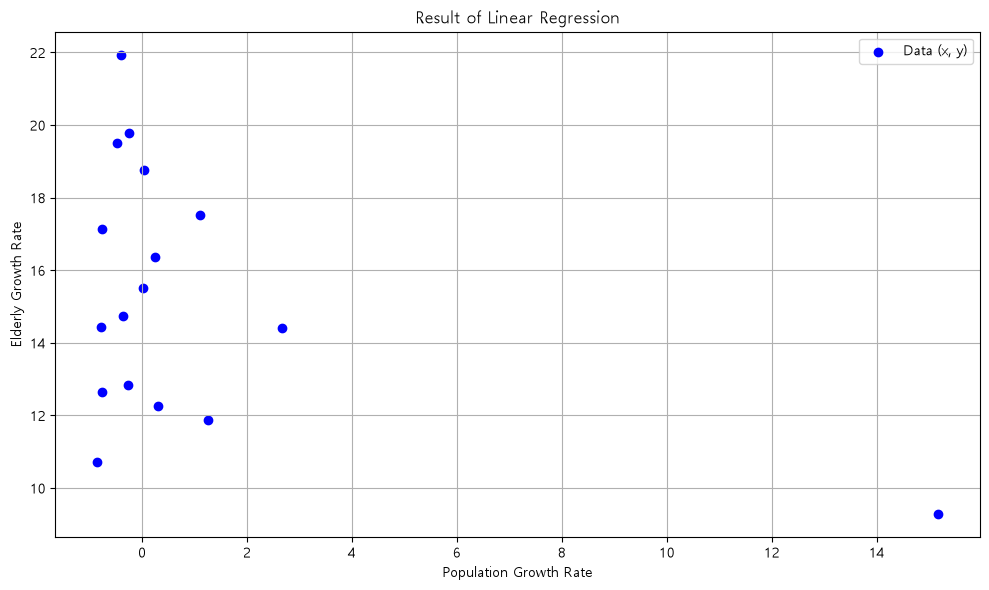

In [47]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc 
import platform

tf.random.set_seed(0)

x_data = np.array([0.3, -0.78, 1.26, 0.03, 1.11, 15.17, 0.24, -0.24, -0.47, -0.77,
                   -0.37, -0.85, -0.41, -0.27, 0.02, -0.76, 2.66], dtype=np.float64)

y_data = np.array([12.27, 14.44,11.87,18.75,17.52,9.29,16.37,19.78,19.51,12.65,
                   14.74,10.72,21.94,12.83,15.51,17.14,14.42], dtype=np.float64)

plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, color = 'blue', label = 'Data (x, y)')
plt.title("Result of Linear Regression")
plt.xlabel("Population Growth Rate")
plt.ylabel("Elderly Growth Rate")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- 한 개의 값만 x의 값이 14 이상인 곳에 위치
- 이상치여서 제거를 해줘야 함

In [48]:
x_data = np.delete(x_data, 5)
y_data = np.delete(y_data, 5)
print(x_data, y_data)

[ 0.3  -0.78  1.26  0.03  1.11  0.24 -0.24 -0.47 -0.77 -0.37 -0.85 -0.41
 -0.27  0.02 -0.76  2.66] [12.27 14.44 11.87 18.75 17.52 16.37 19.78 19.51 12.65 14.74 10.72 21.94
 12.83 15.51 17.14 14.42]


- 이상치를 제거했으니 선형회귀 시작

In [50]:
tf.random.set_seed(0)

x_train = tf.constant(x_data, dtype=np.float64)
y_train = tf.constant(y_data, dtype=np.float64)

w = tf.Variable(tf.random.uniform([1], -1, 1, dtype=tf.float64, seed = 0))
b = tf.Variable(tf.random.uniform([1], 0, 1, dtype=tf.float64, seed = 1))

def hypothesis(w, b):
    return x_train * w + b

def cost(w, b):
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(w,b)- y_train)))

opt = tf.keras.optimizers.SGD(learning_rate = 0.01)

for step in range(5000):
    with tf.GradientTape() as tape:
        loss = cost(w, b)
    gradients = tape.gradient(loss, [w, b])
    opt.apply_gradients(zip(gradients, [w, b]))

    if step % 100 == 0:
        print(step, f"[{loss.numpy()}, {w.numpy()}, {b.numpy()}]")

0 [15.683687453180848, [-0.68328503], [0.32763976]]
100 [14.722875422654958, [-0.62434488], [1.30605452]]
200 [13.76814815637113, [-0.56779053], [2.28149152]]
300 [12.820789158521254, [-0.51382822], [3.2532858]]
400 [11.882454252354616, [-0.4626962], [4.22057193]]
500 [10.955307341809547, [-0.41467134], [5.1822073]]
600 [10.042213625652039, [-0.37007701], [6.13666003]]
700 [9.147015166283454, [-0.3292921], [7.0818439]]
800 [8.2749207251575, [-0.29276033], [8.01487373]]
900 [7.433041739423733, [-0.26099742], [8.93170485]]
1000 [6.631077811785827, [-0.23459014], [9.82661595]]
1100 [5.8820434946398965, [-0.2141745], [10.6915186]]
1200 [5.2026269659400795, [-0.20036893], [11.5151912]]
1300 [4.612190474476142, [-0.1936282], [12.28284926]]
1400 [4.128908443811179, [-0.19400002], [12.97700623]]
1500 [3.762625698412942, [-0.20085366], [13.58079709]]
1600 [3.508146343784112, [-0.21278857], [14.08345694]]
1700 [3.3455749126412853, [-0.22790798], [14.48464021]]
1800 [3.2485946069399048, [-0.24432

In [56]:
#최종 파라미터
final_w = w.numpy()[0]
final_b = b.numpy()[0]
print(f"최종 선형 회귀식: y = {final_w:.4f}x + {final_b:.4f}")

#예측 결과
y_pred = final_w * x_data + final_b
print(y_pred)

최종 선형 회귀식: y = -0.3558x + 15.6693
[15.56254407 15.94677305 15.2210072  15.65860132 15.27437234 15.58389013
 15.75465856 15.83648511 15.94321538 15.80090835 15.97167678 15.81513905
 15.76533159 15.66215899 15.9396577  14.72293259]


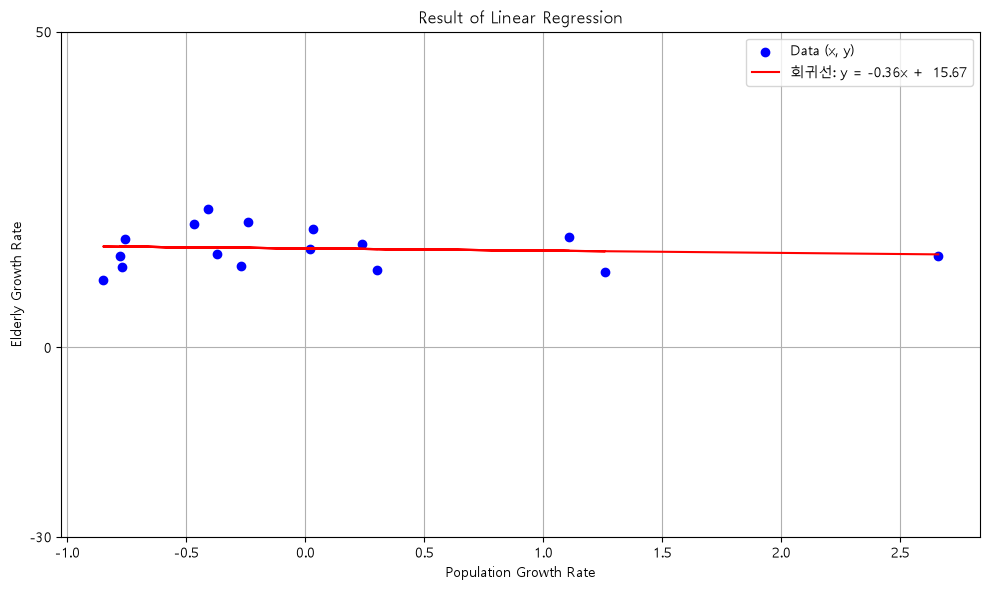

In [64]:
#시각화
plt.figure(figsize=(10,6))
plt.scatter(x_data, y_data, color = 'blue', label = 'Data (x, y)')
plt.plot(x_data, y_pred, color = 'red', label = f'회귀선: y = {final_w:.2f}x + {final_b: .2f}')
plt.title("Result of Linear Regression")
plt.xlabel("Population Growth Rate")
plt.ylabel("Elderly Growth Rate")
plt.yticks([-30, 0, 50])
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

- 다중 선형 회귀

In [15]:
import tensorflow as tf

#x, y의 데이터 값
#차례대로 x1: 공부시간, x2: 학원 횟수, y: 시험 점수
data = [[2, 0, 81], [4, 4, 93], [6, 2, 91], [8, 3, 97]]

x1 = [x_row[0] for x_row in data]
x2 = [x_row2[1] for x_row2 in data]
y_data = [y_row[2] for y_row in data]

w1 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
w2 = tf.Variable(tf.random.uniform([1], 0, 10, dtype=tf.float64, seed=0))
b = tf.Variable(tf.random.uniform([1], 0, 100, dtype=tf.float64, seed=0))

def hypothesis(w1, w2 ,b):
    return x1 * w1 + x2 * w2 + b
def cost(w1, w2, b):
    return tf.sqrt(tf.reduce_mean(tf.square(hypothesis(w1, w2 ,b) - y_data)))

opt = tf.keras.optimizers.SGD(learning_rate = 0.1)
for i in range(5000):
    #자동 미분을 위한 테이프
    with tf.GradientTape() as tape:
        current_cost = cost(w1, w2, b) #기록할 내용이 w, b임을 명시
    gradients = tape.gradient(current_cost, [w1, w2, b]) #손실에 대한 w, b의 미분값 계산
    opt.apply_gradients(zip(gradients, [w1, w2, b])) #미분값으로 w와 b를 업데이트 (조정)
    if i % 100 == 0:
        print(i, f'{current_cost.numpy()}, {w1.numpy()}, {w2.numpy()}, {b.numpy()}')

0 62.06656739774148, [2.07719391], [3.42397601], [13.44266186]
100 23.966992272022225, [9.72699799], [6.19797987], [18.48448354]
200 22.362471482455376, [9.33953841], [5.58925837], [22.42385525]
300 20.770076629993646, [8.87517072], [5.1503032], [26.36255087]
400 19.18207327139747, [8.36318004], [4.81667578], [30.30028516]
500 17.59556477329052, [7.82280662], [4.54590537], [34.23722318]
600 16.00955898994088, [7.26625281], [4.31100934], [38.17359705]
700 14.423759702377017, [6.70095104], [4.09554036], [42.10958099]
800 12.838109567777014, [6.13121775], [3.8899501], [46.04526671]
900 11.252637380470537, [5.55942128], [3.68901336], [49.98066742]
1000 9.667423097848742, [4.98677769], [3.49007389], [53.9157178]
1100 8.08261693248807, [4.41387178], [3.29190566], [57.85024837]
1200 6.498516840133348, [3.84098708], [3.09401901], [61.78389475]
1300 4.915803924317638, [3.26832779], [2.89627919], [65.71580761]
1400 3.336445068483262, [2.69627564], [2.69876124], [69.64351889]
1500 1.7693510604291

In [18]:
#위의 다중 선형 회귀에서 3시간, 5시간 공부했을 때 점수

new_x1 = tf.constant([3.0, 9.0], dtype = tf.float64) #공부 시간
new_x2 = tf.constant([2.0, 5.0], dtype = tf.float64) #학원 횟수

pred_scores = new_x1 * w1 + new_x2 * w2 + b
for hrs, pred in zip(new_x1.numpy(), pred_scores.numpy()):
    print(f"{hrs:.0f}시간 공부 예상 점수 -> {pred:.2f}")

3시간 공부 예상 점수 -> 85.83
9시간 공부 예상 점수 -> 99.70


Matplotlib

In [39]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import platform
from matplotlib import font_manager

if platform.system() == 'Windows':# 윈도우인 경우
    font_path = "c:/Windows/Fonts/malgun.ttf" # 맑은 고딕 폰트 경로
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    plt.rc('font', family=font_name)
elif platform.system() == 'Darwin': # macOS인 경우
    plt.rc('font', family='AppleGothic')
else: # Linux 등 다른 OS인 경우
    plt.rc('font', family='NanumGothic')
# 음수 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

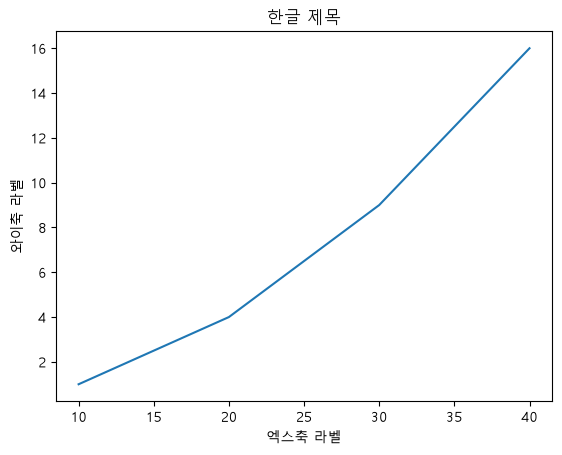

In [40]:
plt.title('한글 제목')
plt.plot([10,20,30,40], [ 1, 4, 9 ,16])
plt.xlabel("엑스축 라벨")
plt.ylabel("와이축 라벨")
plt.show()

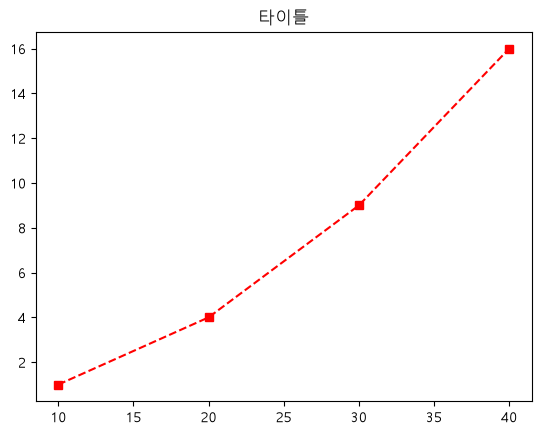

In [41]:
plt.title("타이틀")
plt.plot([10,20,30,40], [ 1, 4, 9 ,16], 'rs--')
plt.show()

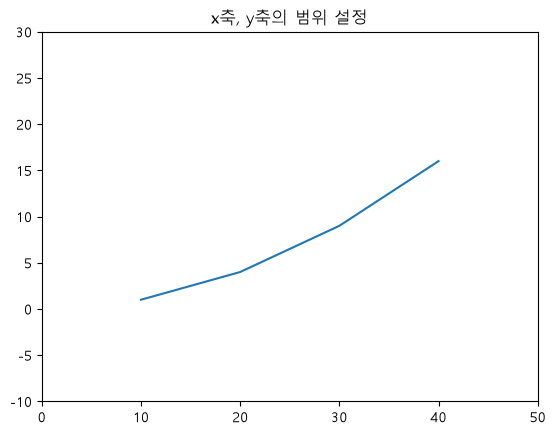

In [51]:
plt.title("x축, y축의 범위 설정")
plt.plot([10,20,30,40], [1,4,9,16])
plt.xlim(0, 50)
plt.ylim(-10, 30)
plt.show()

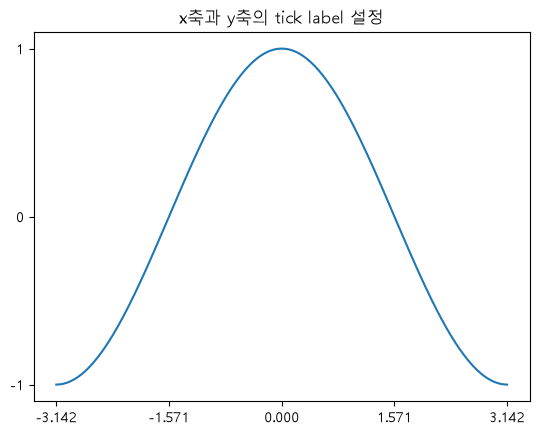

In [54]:
import numpy as np

X = np.linspace(-np.pi, np.pi, 256)
C = np.cos(X)
plt.title("x축과 y축의 tick label 설정")
plt.plot(X, C)
plt.xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi])
plt.yticks([-1, 0, +1])
plt.show()

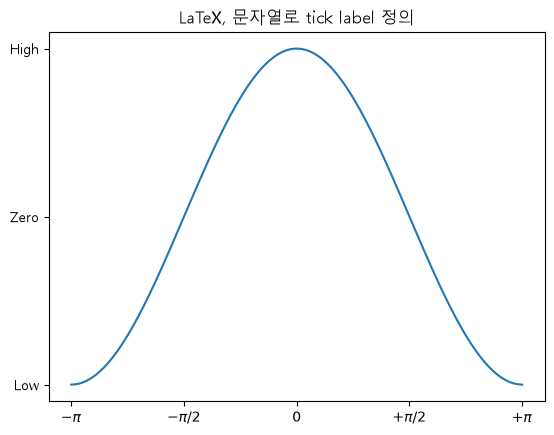

In [55]:
X = np.linspace(-np.pi, np.pi, 256)
C = np.cos(X)
plt.title("LaTeX, 문자열로 tick label 정의")
plt.plot(X, C)
plt.xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
           [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$+\pi/2$', r'$+\pi$'])
plt.yticks([-1, 0, 1], ["Low", "Zero", "High"])
plt.show()

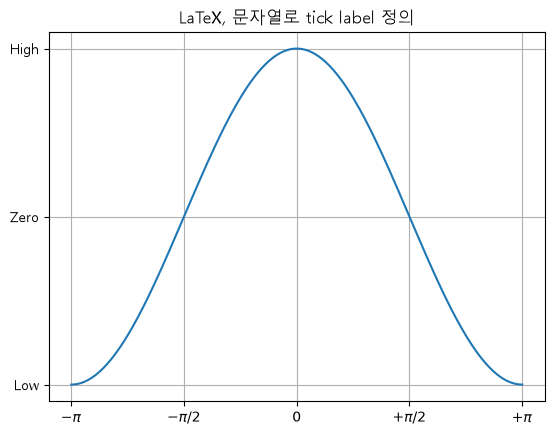

In [ ]:
#grid 추가

X = np.linspace(-np.pi, np.pi, 256)
C = np.cos(X)
plt.title("LaTeX, 문자열로 tick label 정의")
plt.plot(X, C)
plt.xticks([-np.pi, -np.pi / 2, 0, np.pi / 2, np.pi],
           [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$+\pi/2$', r'$+\pi$'])
plt.yticks([-1, 0, 1], ["Low", "Zero", "High"])
plt.grid(True)
plt.show()

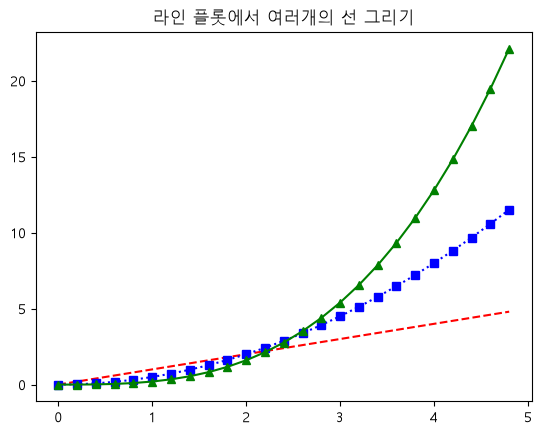

In [61]:
t = np.arange(0., 5, 0.2)
plt.title("라인 플롯에서 여러개의 선 그리기")
plt.plot(t,t, 'r--', t, 0.5*t**2, 'bs:', t, 0.2 * t**3, 'g^-')
plt.show()

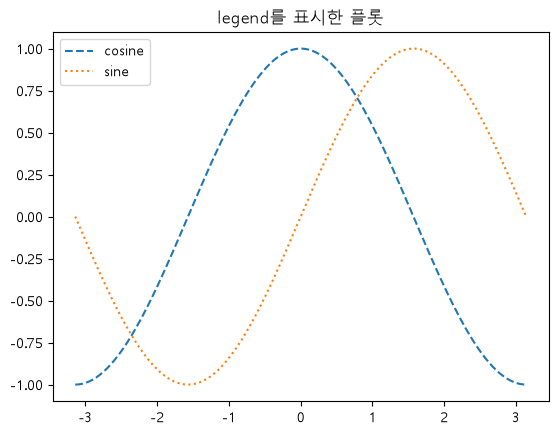

In [65]:
#legend 활용

X = np.linspace(-np.pi, np.pi, 256)
C, S = np.cos(X), np.sin(X)
plt.title("legend를 표시한 플롯")
plt.plot(X, C, ls='--', label = 'cosine')
plt.plot(X,S, ls=":", label="sine")
plt.legend(loc = 0)
plt.show()